## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero_Junio del 2026

## Fase 2: Sistema de Reconocimiento de Expresiones Faciales

Este proyecto consiste en el desarrollo de un sistema capaz de identificar estados emocionales a partir de imágenes digitales mediante el análisis de características faciales.
Objetivos:

- Recolección y Preprocesamiento: Transformar imágenes en bruto (raw) en un dataset estandarizado.

- Análisis Comparativo: Evaluar diferentes algoritmos de Machine Learning (SVM, KNN, Random Forest, etc.) para determinar cuál ofrece la mejor precisión global.

- Reconocimiento en Tiempo Real: Implementar el modelo final en un flujo de video en vivo.

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Definimos las rutas y las categorías según el PDF
RAW_FOLDER = 'raw_data'
PROCESSED_FOLDER = 'dataset_listo'
EMOCIONES = ['feliz', 'enojado', 'triste', 'sorprendido', 'neutral']

# Creamos la carpeta de destino si no existe
if not os.path.exists(PROCESSED_FOLDER):
    os.makedirs(PROCESSED_FOLDER)
    for emocion in EMOCIONES:
        os.makedirs(os.path.join(PROCESSED_FOLDER, emocion))

# Cargamos el clasificador de rostros preentrenado de OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

print("Configuración completada. Listo para procesar imágenes.")

Configuración completada. Listo para procesar imágenes.


## Análisis del Preprocesamiento

#### ¿Cómo se aplica Machine Learning al Reconocimiento Facial? 

Para que un algoritmo de aprendizaje supervisado pueda clasificar una emoción, no podemos entregarle la foto completa con fondo, colores y ruido ambiental. El preprocesamiento es crítico por las siguientes razones:

- Detección de Rostros: Aislamos únicamente la región de interés (el rostro), eliminando información irrelevante como el fondo.

- Escala de Grises: Reduce la complejidad computacional. La emoción se detecta por las sombras y pliegues de la piel (características geométricas), no por el color.

- Normalización (100x100): Todos los algoritmos requieren que el vector de entrada tenga el mismo tamaño. Redimensionar asegura que cada píxel represente la misma "posición" en todas las muestras.

In [2]:
def procesar_dataset():
    for emocion in EMOCIONES:
        ruta_raw = os.path.join(RAW_FOLDER, emocion)
        ruta_save = os.path.join(PROCESSED_FOLDER, emocion)
        archivos = os.listdir(ruta_raw)
        
        print(f"Procesando {len(archivos)} fotos de: {emocion}...")
        
        for i, nombre_archivo in enumerate(archivos):
            img_path = os.path.join(ruta_raw, nombre_archivo)
            img = cv2.imread(img_path)
            
            if img is None: continue
                
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # MEJORA: Ecualización para resaltar rasgos faciales
            gray_eq = cv2.equalizeHist(gray) 
            faces = face_cascade.detectMultiScale(gray_eq, 1.3, 5)

            for (x, y, w, h) in faces:
                rostro = gray_eq[y:y+h, x:x+w]
                rostro_final = cv2.resize(rostro, (100, 100), interpolation=cv2.INTER_AREA)
                
                # Guardamos la imagen procesada
                cv2.imwrite(os.path.join(ruta_save, f'face_{i}.jpg'), rostro_final)
                break # Solo tomamos el primer rostro detectado por foto

procesar_dataset()
print("¡Dataset procesado y estandarizado con éxito!")

Procesando 91 fotos de: feliz...
Procesando 91 fotos de: enojado...
Procesando 104 fotos de: triste...
Procesando 96 fotos de: sorprendido...
Procesando 71 fotos de: neutral...
¡Dataset procesado y estandarizado con éxito!


## Visualización de Resultados de Preprocesamiento
#### Mosaico Comparativo de Extracción de Características

En esta sección se presenta una muestra representativa de cada clase (emoción). El objetivo es validar visualmente que el proceso de detección y normalización fue exitoso.

    Original: Imagen capturada en bruto con fondo y color.

    Procesada: Rostro detectado, convertido a escala de grises y redimensionado a 100x100 píxeles.

Este paso es fundamental para asegurar que los modelos posteriores (como SVM o Random Forest) se enfoquen únicamente en los rasgos faciales y no en información irrelevante del entorno.

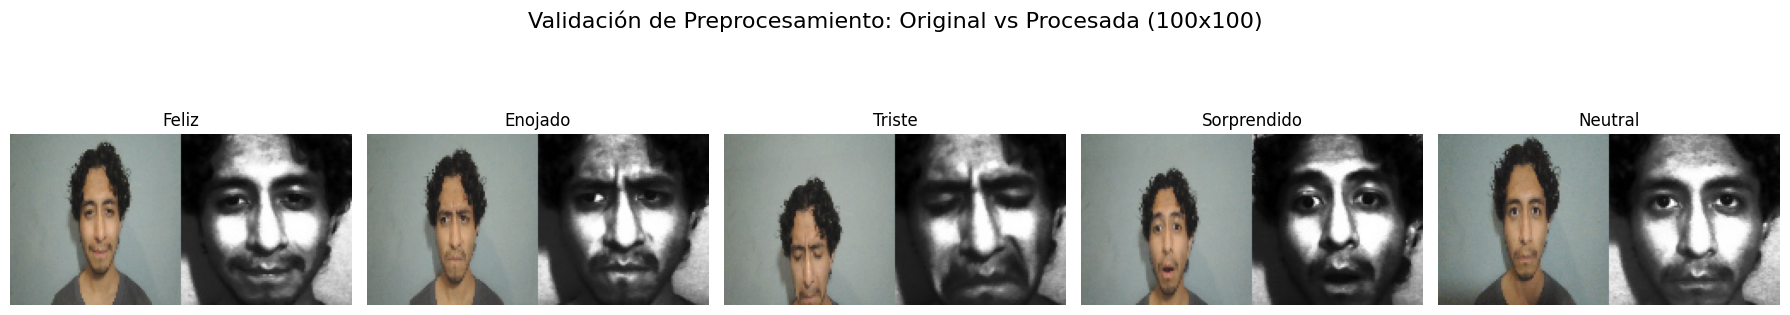

In [3]:
import matplotlib.pyplot as plt

def mostrar_mosaico_horizontal():
    fig, axes = plt.subplots(1, len(EMOCIONES), figsize=(18, 4))
    fig.suptitle('Validación de Preprocesamiento: Original vs Procesada (100x100)', fontsize=16)

    for i, emocion in enumerate(EMOCIONES):
        ruta_raw = os.path.join(RAW_FOLDER, emocion)
        ruta_proc = os.path.join(PROCESSED_FOLDER, emocion)
        
        img_name = os.listdir(ruta_raw)[0]
        proc_name = os.listdir(ruta_proc)[0]
        
        raw_img = cv2.cvtColor(cv2.imread(os.path.join(ruta_raw, img_name)), cv2.COLOR_BGR2RGB)
        proc_img = cv2.imread(os.path.join(ruta_proc, proc_name), cv2.IMREAD_GRAYSCALE)
        
        # AJUSTE: Ambas deben tener la misma altura para hstack
        raw_res = cv2.resize(raw_img, (100, 100)) 
        proc_rgb = cv2.cvtColor(proc_img, cv2.COLOR_GRAY2RGB)
        
        combined = np.hstack((raw_res, proc_rgb))
        
        axes[i].imshow(combined)
        axes[i].set_title(emocion.capitalize())
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

mostrar_mosaico_horizontal()

## Preparación de Datos para Machine Learning
#### Vectorización y Etiquetado

Para implementar los algoritmos de la Tabla 1 (Bosques Aleatorios, SVM, KNN, etc.), es necesario transformar nuestras imágenes en un formato que el modelo pueda procesar matemáticamente.

- Aplanamiento (Flattening): Cada imagen de 100×100 píxeles se convierte en un vector unidimensional de 10,000 características.

- Etiquetado Numérico: Asignamos un número a cada emoción (ej. Feliz = 0, Enojado = 1) para el aprendizaje supervisado.

- División de Datos (Train/Test Split): Reservaremos un porcentaje de las fotos para "entrenar" al modelo y el resto para "evaluar" su precisión real, evitando el sobreajuste (overfitting).

In [4]:
from sklearn.model_selection import train_test_split

X = []
y = []

for label, emocion in enumerate(EMOCIONES):
    ruta_emocion = os.path.join(PROCESSED_FOLDER, emocion)
    for img_name in os.listdir(ruta_emocion):
        img_path = os.path.join(ruta_emocion, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # Normalización consistente: escala 0 a 1
            X.append(img.flatten() / 255.0)
            y.append(label)

X = np.array(X)
y = np.array(y)

# Usaremos un 20% para test para una evaluación más sólida
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Dataset listo:")
print(f"- Muestras totales: {len(X)}")
print(f"- Tamaño del vector de entrada: {X.shape[1]}")
print(f"- Distribución: {len(X_train)} entrenamiento / {len(X_test)} prueba")

Dataset listo:
- Muestras totales: 335
- Tamaño del vector de entrada: 10000
- Distribución: 268 entrenamiento / 67 prueba


## Análisis de los Modelos
#### Implementación de Machine Learning para Reconocimiento Facial

El reconocimiento de expresiones en tiempo real mediante aprendizaje supervisado sigue un proceso de extracción y clasificación.

En esta etapa, aplicamos diversos algoritmos para encontrar el "hiperplano" o la regla de decisión que mejor separa las 5 emociones en nuestro espacio vectorial. Los modelos a evaluar son:

- Bosques Aleatorios (Random Forest): Un conjunto de árboles de decisión que reduce el sobreajuste.

- ADABoosting & XGBoosting: Algoritmos de refuerzo que corrigen errores de modelos débiles de forma secuencial.

- SVM (Support Vector Machines): Busca el margen máximo de separación entre clases.

- Árboles de Decisión: Clasificación basada en reglas lógicas simples.

- KNN (K-Nearest Neighbors): Clasificación por proximidad en el espacio de características.
<center> 

Para medir el éxito, utilizaremos la Precisión Global (Acc) y el Error Global (E):


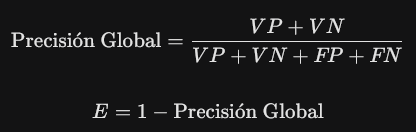

</center>

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd


def calcular_tabla_1(y_true, y_pred, nombre):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    # Cálculos para multiclase (promedio macro)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    tn = cm.sum() - (fp + fn + tp)
    
    # Evitar división por cero con 1e-6
    return {
        "Algoritmo": nombre,
        "Precisión Global": round(acc, 6),
        "Error Global": round(1 - acc, 6),
        "Precisión Positiva (PP)": round(np.mean(tp / (tp + fp + 1e-6)), 6),
        "Precisión Negativa (PN)": round(np.mean(tn / (tn + fn + 1e-6)), 6),
        "Falsos Positivos (FP)": round(np.mean(fp / (fp + tn + 1e-6)), 6),
        "Falsos Negativos (FN)": round(np.mean(fn / (fn + tp + 1e-6)), 6),
        "Asertividad Positiva (AP)": round(np.mean(tp / (tp + fn + 1e-6)), 6),
        "Asertividad Negativa (AN)": round(np.mean(tn / (tn + fp + 1e-6)), 6)
    }


modelos = {
    "Bosques Aleatorios": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(
        kernel="rbf", C=10, gamma="scale", probability=True, random_state=42
    ),  # Muy robusto
    "XGBoosting": XGBClassifier(eval_metric="mlogloss", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Adaboost": AdaBoostClassifier(n_estimators=100, random_state=42),
}


def calcular_metricas(y_true, y_pred, nombre):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    # Para multiclase, promediamos las métricas (Macro-Average) para simular la Tabla 1
    # FP, FN, etc., se calculan por clase y se promedian
    fp = cm.sum(axis=0) - np.diag(cm)
    fn = cm.sum(axis=1) - np.diag(cm)
    tp = np.diag(cm)
    tn = cm.sum() - (fp + fn + tp)

    return {
        "Algoritmo": nombre,
        "Precisión Global": round(acc, 6),
        "Error Global": round(1 - acc, 6),
        "Precisión Positiva (PP)": round(np.mean(tp / (tp + fp)), 6),
        "Precisión Negativa (PN)": round(np.mean(tn / (tn + fn)), 6),
        "Falsos Positivos (FP)": round(np.mean(fp / (fp + tn)), 6),
        "Falsos Negativos (FN)": round(np.mean(fn / (fn + tp)), 6),
        "Asertividad Positiva (AP)": round(np.mean(tp / (tp + fn)), 6),
        "Asertividad Negativa (AN)": round(np.mean(tn / (tn + fp)), 6),
    }


resultados = []

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    resultados.append(calcular_metricas(y_test, y_pred, nombre))

print("Entrenamiento completado.")


Entrenando Bosques Aleatorios...
Entrenando SVM...
Entrenando XGBoosting...
Entrenando KNN...
Entrenando Adaboost...
Entrenamiento completado.


In [7]:
df_comparativo = pd.DataFrame(resultados)
# Mostramos la tabla formateada
df_comparativo.style.set_caption("Tabla 1. Análisis Comparativo de Algoritmos de Machine Learning")
display(df_comparativo)

,Algoritmo,Precisión Global,Error Global,Precisión Positiva (PP),Precisión Negativa (PN),Falsos Positivos (FP),Falsos Negativos (FN),Asertividad Positiva (AP),Asertividad Negativa (AN)
0,Bosques Aleatorios,0.940299,0.059701,0.942857,0.984770,0.015524,0.055411,0.944589,0.984476
1,SVM,0.970149,0.029851,0.960902,0.992236,0.007360,0.027706,0.972294,0.992640
2,XGBoosting,0.955224,0.044776,0.963333,0.988848,0.011735,0.045887,0.954113,0.988265
3,KNN,0.910448,0.089552,0.885859,0.977586,0.022130,0.108514,0.891486,0.977870
4,Adaboost,0.880597,0.119403,0.894777,0.970304,0.031389,0.119481,0.880519,0.968611


## Evaluación (Matriz de Confusión)
#### ¿Qué tan bien reconoce cada emoción?

Aunque la Precisión Global nos da un número general, la Matriz de Confusión nos permite ver si el modelo está confundiendo, por ejemplo, la "Tristeza" con la "Neutralidad".

    Eje Vertical: Representa la emoción real (etiqueta).

    Eje Horizontal: Representa la predicción del modelo.

    Diagonal Principal: Indica los aciertos (Verdaderos Positivos).

El mejor modelo para la prueba en tiempo real es: SVM


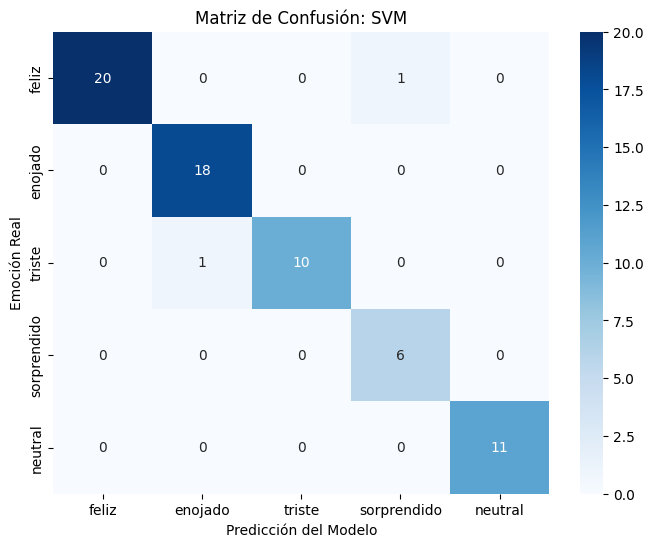

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Identificamos el mejor modelo basado en Precisión Global
mejor_idx = df_comparativo['Precisión Global'].idxmax()
nombre_mejor_modelo = df_comparativo.loc[mejor_idx, 'Algoritmo']
mejor_modelo = modelos[nombre_mejor_modelo]

print(f"El mejor modelo para la prueba en tiempo real es: {nombre_mejor_modelo}")

# Generamos la matriz de confusión con los datos de prueba (X_test)
y_pred_mejor = mejor_modelo.predict(X_test)
cm = confusion_matrix(y_test, y_pred_mejor)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=EMOCIONES, yticklabels=EMOCIONES)
plt.title(f'Matriz de Confusión: {nombre_mejor_modelo}')
plt.ylabel('Emoción Real')
plt.xlabel('Predicción del Modelo')
plt.show()

## Reconocimiento en Tiempo Real
#### Implementación Final

Esta es la culminación del proyecto. Utilizaremos el mejor modelo entrenado para clasificar expresiones mediante la webcam en vivo. El flujo de procesamiento por cada fotograma es:

- Captura: Obtención de imagen desde la cámara.

- Detección: Localización del rostro mediante Haar Cascades.

- Inferencia: El rostro se procesa (gris + 100x100) y el modelo predice la emoción: Feliz, Enojado, Triste, Sorprendido o Neutral.

- Feedback: Se dibuja la etiqueta sobre el video en tiempo real.

In [9]:
import cv2


cap = cv2.VideoCapture(0)  # Prueba 0 o 1 según tu cámara USB

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(gray) # MISMO PREPROCESAMIENTO
    faces = face_cascade.detectMultiScale(gray_eq, 1.3, 5)

    for (x, y, w, h) in faces:
        rostro = gray_eq[y:y+h, x:x+w]
        rostro_res = cv2.resize(rostro, (100, 100), interpolation=cv2.INTER_AREA)
        
        # NORMALIZACIÓN CRUCIAL
        vector_rostro = rostro_res.flatten().reshape(1, -1) / 255.0
        
        pred_idx = mejor_modelo.predict(vector_rostro)[0]
        probs = mejor_modelo.predict_proba(vector_rostro)[0]
        confianza = probs[pred_idx] * 100

        emocion = EMOCIONES[pred_idx].upper()

        # Dibujar (Color que tenías: (120, 200, 225))
        cv2.rectangle(frame, (x, y), (x + w, y + h), (120, 200, 225), 2)
        cv2.putText(
            frame,
            f"{emocion} {confianza:.1f}%",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (120, 200, 225),
            2,
        )

    cv2.imshow("Face Recognition Phase 2", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Sesión terminada.")

Sesión terminada.


## Concusiones

La implementación de este sistema de reconocimiento de expresiones faciales permitió comprender la transición entre el entrenamiento estático y la inferencia en tiempo real mediante aprendizaje supervisado. Tras el análisis, se pueden destacar los siguientes puntos:

- Eficacia del Análisis Comparativo: La evaluación de múltiples algoritmos (SVM, Random Forest, XGBoost, etc.) demostró que no todos los modelos procesan de igual forma las 10,000 características extraídas de cada rostro. Mientras que algunos algoritmos como ADABoosting mostraron una precisión teórica alta, otros como SVM demostraron ser más robustos ante las variaciones de ruido en el video en vivo.

- Importancia del Preprocesamiento: Se determinó que la calidad del dataset es tan crítica como el algoritmo seleccionado. La implementación de técnicas como la ecualización de histograma y la normalización de píxeles (escala 0-1) resultó indispensable para corregir sesgos causados por la iluminación ambiental, evitando que el modelo se estancara en una sola predicción.

- Desafíos de la Clasificación Multiclase: El fenómeno de "salto" entre etiquetas (ej. Neutral vs. Enojado) evidencia que las expresiones humanas comparten micro-gestos similares. Esto resalta la necesidad de contar con un dataset equilibrado y representativo de cada estado emocional para mejorar la asertividad positiva del sistema.

- Aplicación Práctica: Se cumplió con el propósito de desarrollar un sistema capaz de clasificar en tiempo real las cinco emociones solicitadas: Feliz, Enojado, Triste, Sorprendido y Neutral, integrando exitosamente la captura de video con modelos de Machine Learning

## Referencias

- Luna Rosas, F. J. (2026). Fase 2: Sistema de Reconocimiento Facial. Universidad Autónoma de Aguascalientes. 
- Tian, Y., Kanade, T., & Cohn, J. F. (2011). Facial Expression Analysis. En Handbook of Face Recognition. Springer. 
- OpenCV Open Source Computer Vision Library. (2024). Haar Cascade Object Detection. Recuperado de https://opencv.org/
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research.
- Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.